Install Dependencies

In [1]:

!pip install -q ultralytics
!pip install -q opencv-python
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 22.5 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset Description

- Input: Leaf Images
- Ground Truth: Pixel-level segmentation masks
- Goal: Convert segmentation masks → detection labels for YOLO training


DOWNLOAD DATASET


In [3]:
import os
from google.colab import userdata

# Replace these with your actual Kaggle credentials
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Now run your commands
!kaggle datasets download -d ankanghosh651/leaf-sengmentation-dataset-sam2-format
!unzip -q leaf-sengmentation-dataset-sam2-format.zip -d leaf-seg

Dataset URL: https://www.kaggle.com/datasets/ankanghosh651/leaf-sengmentation-dataset-sam2-format
License(s): MIT
100% 51.5M/51.5M [00:04<00:00, 11.9MB/s]



In [4]:
import os
print(os.listdir())

['.config', 'leaf-seg', 'leaf-sengmentation-dataset-sam2-format.zip', 'sample_data']


In [5]:
import os
print(os.listdir("leaf-seg"))

['leaf-seg']


In [6]:
import os

for root, dirs, files in os.walk("leaf-seg"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("------")

Folder: leaf-seg
Subfolders: ['leaf-seg']
Files: []
------
Folder: leaf-seg/leaf-seg
Subfolders: ['masks', 'images']
Files: ['train.csv']
------
Folder: leaf-seg/leaf-seg/masks
Subfolders: []
Files: ['00176.png', '00040.png', '00260.png', '00429.png', '00179.png']
------
Folder: leaf-seg/leaf-seg/images
Subfolders: []
Files: ['00013.jpg', '00121.jpg', '00436.jpg', '00540.jpg', '00311.jpg']
------


Random Sample

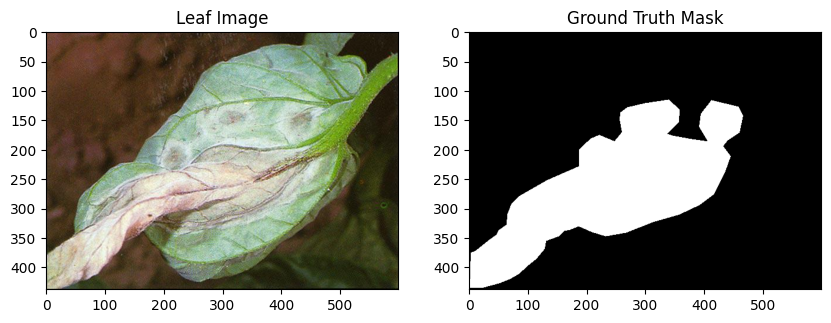

In [7]:
data_dir = "leaf-seg/leaf-seg"
images_dir = os.path.join(data_dir, "images")
masks_dir = os.path.join(data_dir, "masks")

df = pd.read_csv(os.path.join(data_dir, "train.csv"))

row = df.sample(1).iloc[0]

img_path = os.path.join(images_dir, row["imageid"])
mask_path = os.path.join(masks_dir, row["maskid"])

image = cv2.imread(img_path)
mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Leaf Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.show()

In [8]:
df.head()

,imageid,maskid
0,00000.jpg,00000.png
1,00001.jpg,00001.png
2,00002.jpg,00002.png
3,00003.jpg,00003.png
4,00004.jpg,00004.png


## Converting Segmentation Masks → Bounding Boxes
We extract contours from masks and compute bounding rectangles.

Convert Masks → YOLO Format

In [9]:


yolo_images = "yolo_dataset/images/train"
yolo_labels = "yolo_dataset/labels/train"

os.makedirs(yolo_images, exist_ok=True)
os.makedirs(yolo_labels, exist_ok=True)

for _, row in df.iterrows():

    img_path = os.path.join(images_dir, row["imageid"])
    mask_path = os.path.join(masks_dir, row["maskid"])

    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    h, w = mask.shape

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    label_lines = []

    for cnt in contours:
        if cv2.contourArea(cnt) < 50:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)

        xc = (x + bw/2) / w
        yc = (y + bh/2) / h
        bw /= w
        bh /= h

        label_lines.append(f"0 {xc} {yc} {bw} {bh}")

    cv2.imwrite(os.path.join(yolo_images, row["imageid"]), image)

    label_path = os.path.join(
        yolo_labels,
        row["imageid"].replace(".jpg",".txt")
    )

    with open(label_path, "w") as f:
        f.write("\n".join(label_lines))

Create YOLO Config

In [10]:
%%writefile leaf.yaml
path: yolo_dataset
train: images/train
val: images/train

names:
  0: disease

Writing leaf.yaml


Train YOLOv8n

In [11]:
model = YOLO("yolov8s.pt")

model.train(
    data="leaf.yaml",
    epochs=40,
    imgsz=640,
    batch=16,

    # 🔥 AUGMENTATION
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15,
    translate=0.1,
    scale=0.5,
    shear=2,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=leaf.yaml, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

IndexError: Caught IndexError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/data/base.py", line 380, in __getitem__
    return self.transforms(self.get_image_and_label(index))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py", line 187, in __call__
    data = t(data)
           ^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py", line 2064, in __call__
    sem_masks = cls_tensor[ma

In [ ]:
model.val()

Download Lightweight SAM

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

Test On Random Image

In [ ]:
from segment_anything import sam_model_registry, SamPredictor

device = "cuda"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

predictor = SamPredictor(sam)

In [ ]:

# def automatic_segmentation(image_path):

#     image = cv2.imread(image_path)

#     if image is None:
#         raise ValueError("Image not found:", image_path)

#     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#     results = model(image_rgb)
#     boxes = results[0].boxes.xyxy.cpu().numpy()

#     predictor.set_image(image_rgb)

#     final_mask = np.zeros(image_rgb.shape[:2])

#     for box in boxes:
#         with torch.no_grad():
#             masks, _, _ = predictor.predict(
#                 box=box.reshape(1,4),
#                 multimask_output=False
#             )

#         final_mask = np.logical_or(final_mask, masks[0])

#     return image_rgb, final_mask.astype(np.uint8)

In [ ]:
def automatic_segmentation(image_path):

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found:", image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # -------- YOLO Detection --------
    results = model(image_rgb)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("No detection.")
        return image_rgb, np.zeros(image_rgb.shape[:2])

    final_mask = np.zeros(image_rgb.shape[:2])

    for box in boxes:

        x1, y1, x2, y2 = map(int, box)

        crop = image[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)

        # -------- Disease color threshold (tighter brown range) --------
        lower = np.array([5, 80, 20])
        upper = np.array([25, 255, 200])
        disease_mask = cv2.inRange(hsv, lower, upper)

        kernel = np.ones((5,5), np.uint8)
        disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)

        # -------- Foreground points via contour centers --------
        contours, _ = cv2.findContours(
            disease_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        fg_points = []

        for cnt in contours:
            if cv2.contourArea(cnt) < 30:
                continue

            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                fg_points.append([cx, cy])

        if len(fg_points) == 0:
            continue

        fg_points = np.array(fg_points)

        # -------- Background points near border --------
        border_mask = np.zeros_like(disease_mask)
        border_mask[0:10,:] = 1
        border_mask[-10:,:] = 1
        border_mask[:,0:10] = 1
        border_mask[:,-10:] = 1

        ys_bg, xs_bg = np.where(border_mask > 0)

        bg_count = min(10, len(xs_bg))
        bg_idx = np.random.choice(len(xs_bg), bg_count, replace=False)
        bg_points = np.array([[xs_bg[i], ys_bg[i]] for i in bg_idx])

        # -------- Combine prompts --------
        point_coords = np.vstack([fg_points, bg_points])
        point_labels = np.array([1]*len(fg_points) + [0]*len(bg_points))

        predictor.set_image(crop_rgb)

        with torch.no_grad():
            masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=False
            )

        mask_crop = masks[0]

        # Optional: smooth mask
        kernel = np.ones((7,7), np.uint8)
        mask_crop = cv2.morphologyEx(
            mask_crop.astype(np.uint8), cv2.MORPH_CLOSE, kernel
        )

        final_mask[y1:y2, x1:x2] = np.logical_or(
            final_mask[y1:y2, x1:x2],
            mask_crop
        )

    return image_rgb, final_mask.astype(np.uint8)

Test

In [ ]:
import random

In [ ]:
# image_folder = images_dir
# random_image = random.choice(os.listdir(image_folder))
# image_path = os.path.join(image_folder, random_image)

# print("Testing on:", image_path)

# img, mask = automatic_segmentation(image_path)

# plt.figure(figsize=(10,5))
# plt.subplot(1,2,1)
# plt.imshow(img)
# plt.title("Input Image")

# plt.subplot(1,2,2)
# plt.imshow(mask, cmap="gray")
# plt.title("Predicted Mask")
# plt.show()

Test On Random Image

In [ ]:
image_folder = images_dir
random_image = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, random_image)

print("Testing on:", image_path)

img, mask = automatic_segmentation(image_path)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Mask")
plt.show()

In [ ]:
def calculate_disease_percentage(mask):
    disease_pixels = np.sum(mask > 0)
    total_pixels = mask.shape[0] * mask.shape[1]
    return (disease_pixels / total_pixels) * 100

percent = calculate_disease_percentage(mask)

print(f"Disease Area: {percent:.2f}%")

Evaluation Metrics

In [ ]:


def compute_iou(pred_mask, gt_mask):

    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return intersection / union


def compute_dice(pred_mask, gt_mask):

    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred, gt).sum()

    denom = pred.sum() + gt.sum()

    if denom == 0:
        return 1.0

    return (2 * intersection) / denom

🔍 Evaluate On One Random Image

In [ ]:


row = df.sample(1).iloc[0]

image_path = os.path.join(images_dir, row["imageid"])
gt_mask_path = os.path.join(masks_dir, row["maskid"])

print("Evaluating:", image_path)

# Predict
img, pred_mask = automatic_segmentation(image_path)

# Load GT
gt_mask = cv2.imread(gt_mask_path, 0)

# Resize prediction if needed
if pred_mask.shape != gt_mask.shape:
    pred_mask = cv2.resize(
        pred_mask,
        (gt_mask.shape[1], gt_mask.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

iou = compute_iou(pred_mask, gt_mask)
dice = compute_dice(pred_mask, gt_mask)

print(f"IoU  : {iou:.4f}")
print(f"Dice : {dice:.4f}")

# Visualize
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")

plt.show()

Full Dataset Evaluation

In [ ]:


num_samples = 100   # kept small and you may increase if GPU time allows

ious = []
dices = []

sample_df = df.sample(num_samples)

for _, row in sample_df.iterrows():

    image_path = os.path.join(images_dir, row["imageid"])
    gt_mask_path = os.path.join(masks_dir, row["maskid"])

    _, pred_mask = automatic_segmentation(image_path)
    gt_mask = cv2.imread(gt_mask_path, 0)

    if pred_mask.shape != gt_mask.shape:
        pred_mask = cv2.resize(
            pred_mask,
            (gt_mask.shape[1], gt_mask.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    ious.append(compute_iou(pred_mask, gt_mask))
    dices.append(compute_dice(pred_mask, gt_mask))

print("===================================")
print(f"Average IoU  : {np.mean(ious):.4f}")
print(f"Average Dice : {np.mean(dices):.4f}")
print("===================================")

Yolov8s-seg


In [12]:
import os
import cv2
import numpy as np

images_out = "yolo_seg/images/train"
labels_out = "yolo_seg/labels/train"

os.makedirs(images_out, exist_ok=True)
os.makedirs(labels_out, exist_ok=True)

for _, row in df.iterrows():

    img_path = os.path.join(images_dir, row["imageid"])
    mask_path = os.path.join(masks_dir, row["maskid"])

    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    h, w = mask.shape

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    label_lines = []

    for cnt in contours:
        if cv2.contourArea(cnt) < 50:
            continue

        # Normalize contour points
        cnt = cnt.squeeze()

        if len(cnt.shape) != 2:
            continue

        segmentation = []

        for point in cnt:
            x = point[0] / w
            y = point[1] / h
            segmentation.append(f"{x} {y}")

        label_line = "0 " + " ".join(segmentation)
        label_lines.append(label_line)

    # Save image
    cv2.imwrite(os.path.join(images_out, row["imageid"]), image)

    # Save label
    label_file = os.path.join(labels_out, row["imageid"].replace(".jpg",".txt"))

    with open(label_file, "w") as f:
        f.write("\n".join(label_lines))

In [13]:
%%writefile leaf_seg.yaml
path: yolo_seg
train: images/train
val: images/train

names:
  0: disease

Writing leaf_seg.yaml


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")

model.train(
    data="leaf_seg.yaml",
    epochs=40,
    imgsz=640,
    batch=16,

    # 🔥 augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=leaf_seg.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1209510e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

Testing


In [15]:
import os
import random

image_dir = "yolo_seg/images/train"   # change if needed

random_image = random.choice(os.listdir(image_dir))
image_path = os.path.join(image_dir, random_image)

print("Testing on:", image_path)

Testing on: yolo_seg/images/train/00381.jpg


In [16]:
results = model(image_path)


image 1/1 /content/yolo_seg/images/train/00381.jpg: 640x640 11 diseases, 10.1ms
Speed: 2.7ms preprocess, 10.1ms inference, 16.2ms postprocess per image at shape (1, 3, 640, 640)


In [17]:
masks = results[0].masks

if masks is None:
    print("No masks detected")
else:
    masks = masks.data.cpu().numpy()

In [18]:
import numpy as np

final_mask = np.zeros_like(masks[0])

for m in masks:
    final_mask = np.logical_or(final_mask, m)

final_mask = final_mask.astype(np.uint8)

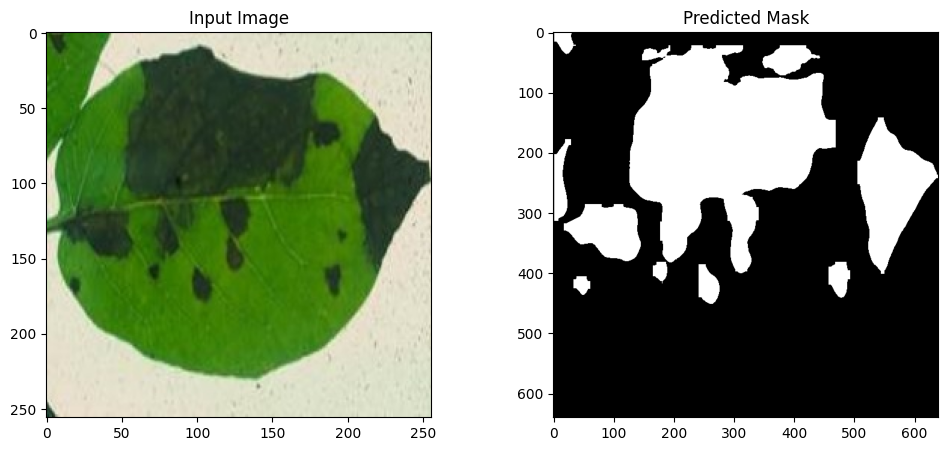

In [19]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(final_mask, cmap="gray")
plt.title("Predicted Mask")

plt.show()

Testing on outside image


In [32]:
results = model("/content/13re-garden-beech-05-kqcp-mediumSquareAt3X.jpg")

mask = results[0].masks.data[0].cpu().numpy()


image 1/1 /content/13re-garden-beech-05-kqcp-mediumSquareAt3X.jpg: 640x640 2 diseases, 21.8ms
Speed: 3.7ms preprocess, 21.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


Testing on outside image: /content/Leaf-spot-diseases.jpg

image 1/1 /content/Leaf-spot-diseases.jpg: 448x640 5 diseases, 60.7ms
Speed: 9.1ms preprocess, 60.7ms inference, 7.2ms postprocess per image at shape (1, 3, 448, 640)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 533 but size of corresponding boolean axis is 448

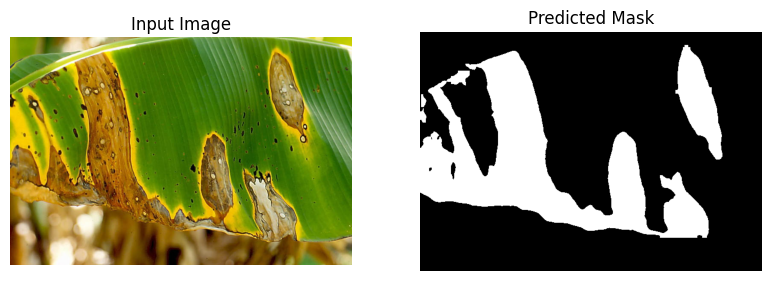

In [38]:
# 🔹 1. Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

# 🔹 2. Load Trained Model
# model = YOLO("/content/runs/detect/train/weights/best.pt")  # change if needed


# 🔹 3. Function: Run Segmentation
def run_segmentation(image_path):

    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Image not found: {image_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run YOLO
    results = model(image_path, conf=0.2)

    # Handle masks safely
    if results[0].masks is None:
        print("⚠️ No segmentation detected")
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    else:
        masks = results[0].masks.data.cpu().numpy()

        # Combine all masks
        mask = np.zeros_like(masks[0])
        for m in masks:
            mask = np.logical_or(mask, m)

        mask = mask.astype(np.uint8)

    return img_rgb, mask


# 🔹 4. OPTION A: Test on Random Dataset Image
def test_random_image(dataset_path):

    images = os.listdir(dataset_path)
    image_name = random.choice(images)
    image_path = os.path.join(dataset_path, image_name)

    print("Testing on:", image_path)

    img, mask = run_segmentation(image_path)
    visualize_results(img, mask)


# 🔹 5. OPTION B: Test on Outside Image
def test_outside_image(image_path):

    print("Testing on outside image:", image_path)

    img, mask = run_segmentation(image_path)
    visualize_results(img, mask)


# 🔹 6. Visualization Function
def visualize_results(img, mask):

    plt.figure(figsize=(15,5))

    # Input image
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    # Mask
    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    # Overlay
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()


# 🔹 7. Disease Percentage
def disease_percentage(mask):
    return (np.sum(mask > 0) / mask.size) * 100


# 🔹 8. RUN EXAMPLES

# 👉 Option A: Random dataset image
# dataset_path = "/content/yolo_seg/images/train"   # change path
# test_random_image(dataset_path)


# 👉 Option B: Outside image
outside_path = "/content/Leaf-spot-diseases.jpg"
test_outside_image(outside_path)

Testing on outside image: /content/zanzibar-gem-leaf-disease-close-260nw-2514952357.webp

image 1/1 /content/zanzibar-gem-leaf-disease-close-260nw-2514952357.webp: 640x448 3 diseases, 335.2ms
Speed: 13.9ms preprocess, 335.2ms inference, 9.6ms postprocess per image at shape (1, 3, 640, 448)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 280 but size of corresponding boolean axis is 640

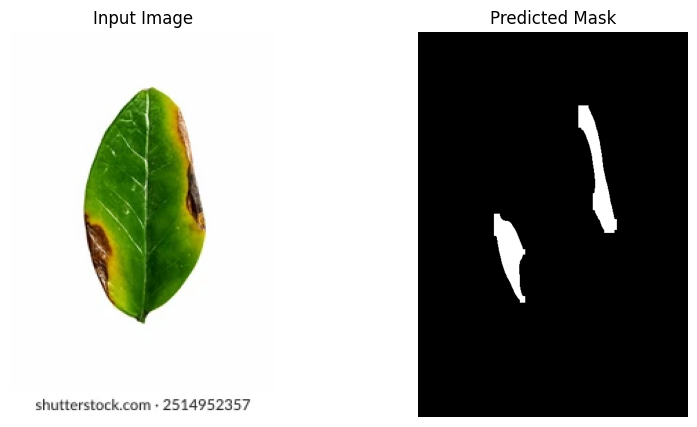

In [41]:
outside_path = "/content/zanzibar-gem-leaf-disease-close-260nw-2514952357.webp"
test_outside_image(outside_path)